# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

**Name:** Dilhara D.S.  

**Index Number:** 230147L 

**GitHub:** [repo link](https://github.com/sachi1645/Intensity-Transformations-and-Neighborhood-Filtering)

### Introduction

This assignment investigates several fundamental image processing techniques,
including intensity transformations, gamma correction, vibrance enhancement,
histogram equalization, Sobel filtering, image interpolation, foreground
segmentation using GrabCut and bilateral filtering.

The objective is to implement these techniques using Python, NumPy and OpenCV,
visualize the results, and compare the performance of different methods.

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'cv2'

# Question 1 — Intensity Transformation

A piecewise-linear intensity transformation is applied to the grayscale image.

The given breakpoints are:

- (0, 0)
- (50, 50)
- (100, 150)
- (150, 255)
- (255, 255)

The transformation is implemented using linear interpolation between
successive breakpoints.

In [ ]:
def intensity_transformation(im, breakpoints):
    im_foloat = im.astype(np.float32)

    output = np.zeros_like(im_foloat)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        mask = (im_foloat >= x1) & (im_foloat < x2)

        if x2 - x1 != 0:
            output[mask] = ((y2 - y1) / (x2 - x1)) * (im_foloat[mask] - x1) + y1

    return np.clip(output, 0, 255).astype(np.uint8)

In [ ]:
im1 = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)

if im1 is None:
    raise FileNotFoundError("Image not found. Please check the path.")

breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255),(150, 150), (255, 255)]

result1 = intensity_transformation(im1, breakpoints)

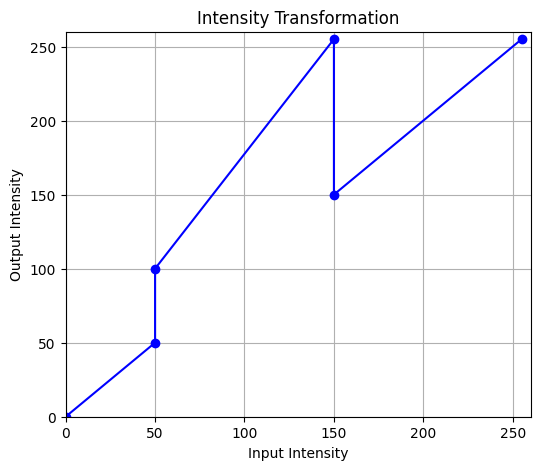

In [ ]:
x = [p[0] for p in breakpoints]
y = [p[1] for p in breakpoints]

plt.figure(figsize=(6, 5))
plt.plot(x, y, 'o-', color='blue', label='Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Intensity Transformation')
plt.xlim(0, 260)
plt.ylim(0, 260)
plt.grid(True)
plt.show()

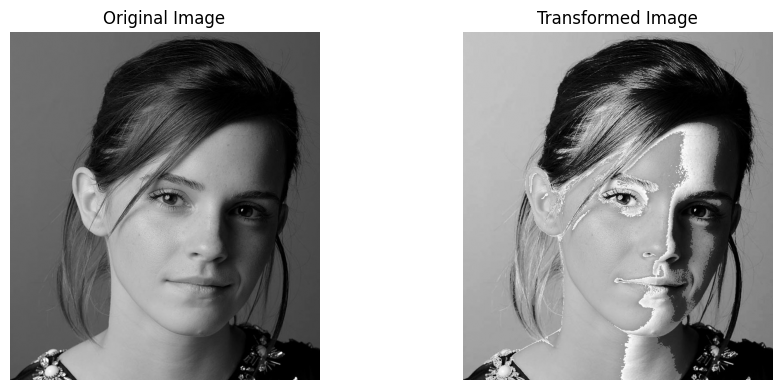

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im1, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result1, cmap='gray')
plt.title('Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

# Question 2 — White Matter and Gray Matter Enhancement

The brain proton-density image is processed using piecewise-linear
intensity transformations.

Two transformations are considered:

1. Enhancement of white matter.
2. Enhancement of gray matter.

The breakpoint values are selected experimentally according to the
intensity distribution of the brain image.

In [ ]:
brain = cv.imread('images/brain.png', cv.IMREAD_GRAYSCALE)

if brain is None:
    raise FileNotFoundError("Image not found. Please check the path.")

white_breakpoints = [(0, 0), (80, 20), (120, 255), (255, 255)]
white_result = intensity_transformation(brain, white_breakpoints)

gray_breakpoints = [(0, 0), (70, 1), (100, 255), (150, 255), (255, 255)]
gray_result = intensity_transformation(brain, gray_breakpoints)

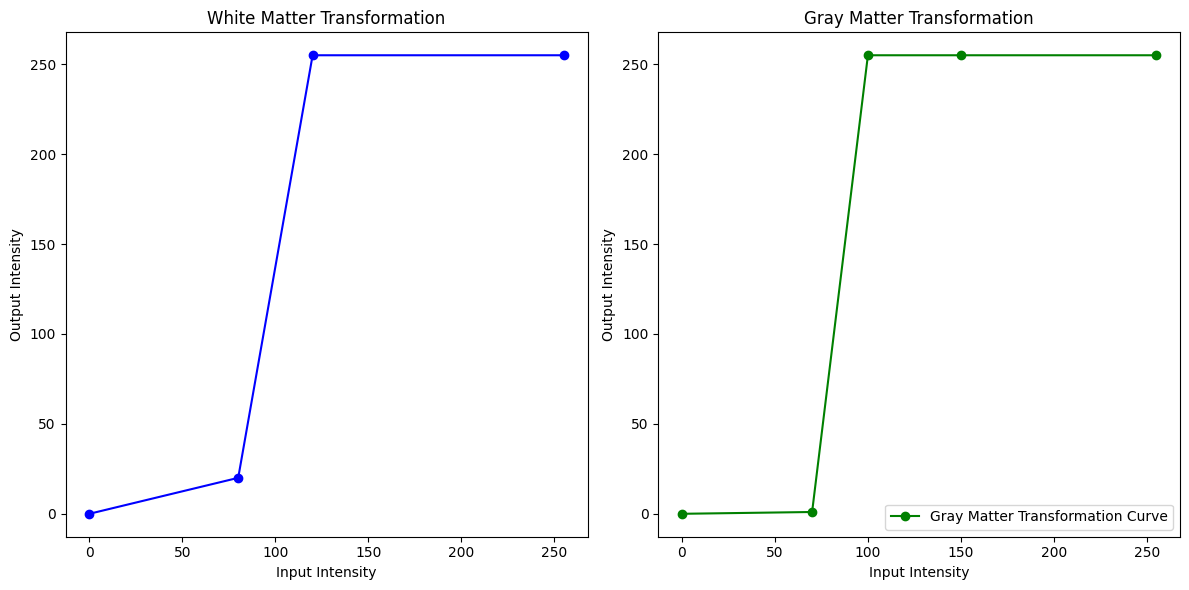

In [ ]:
x_1 = [p[0] for p in white_breakpoints]
y_1 = [p[1] for p in white_breakpoints]

x_2 = [p[0] for p in gray_breakpoints]
y_2 = [p[1] for p in gray_breakpoints]

plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.plot(x_1, y_1, 'o-', color='blue', label='White Matter Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('White Matter Transformation')

plt.subplot(1, 2, 2)
plt.plot(x_2, y_2, 'o-', color='green', label='Gray Matter Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Gray Matter Transformation')
plt.legend()
plt.tight_layout()
plt.show()


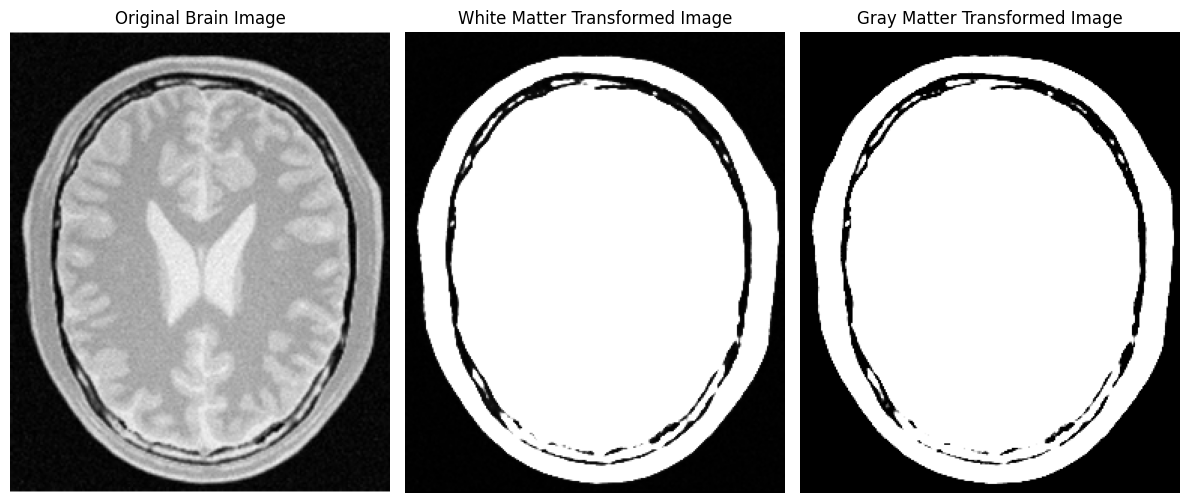

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(brain, cmap='gray')
plt.title('Original Brain Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(white_result, cmap='gray')
plt.title('White Matter Transformed Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gray_result, cmap='gray')
plt.title('Gray Matter Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

# Question 3 — Gamma Correction

Gamma correction is applied only to the L plane of the L*a*b* color space.

The L plane represents image lightness, while the a and b planes represent
color information.

Only the L plane is modified so that the color information is preserved.

In [ ]:
img3 = cv.imread('images/3.webp')

if img3 is None:
    raise FileNotFoundError("Image not found. Please check the path.")

lab = cv.cvtColor(img3, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.7

L_normalized  = L.astype(np.float32) / 255.0
L_gamma_corrected = np.power(L_normalized, gamma)
L_corrected = np.clip(L_gamma_corrected * 255, 0, 255).astype(np.uint8)

lab_corrected = cv.merge((L_corrected, a, b))
img3_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

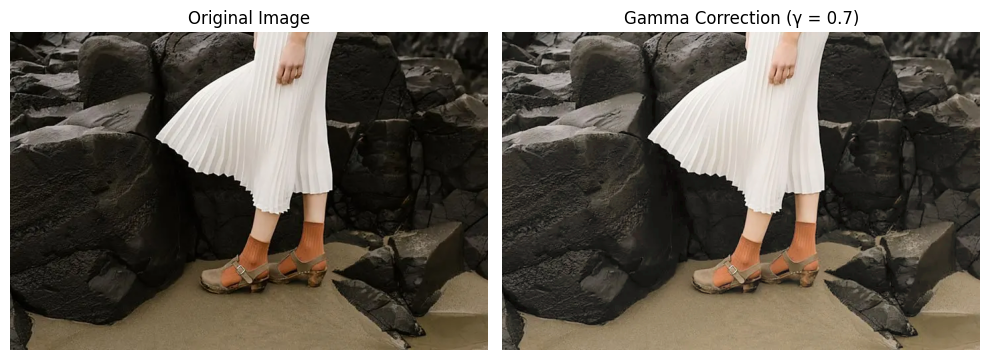

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img3_corrected, cv.COLOR_BGR2RGB))
plt.title('Gamma-Corrected Image')
plt.axis('off')

plt.title(f"Gamma Correction (γ = {gamma})")
plt.tight_layout()
plt.show()

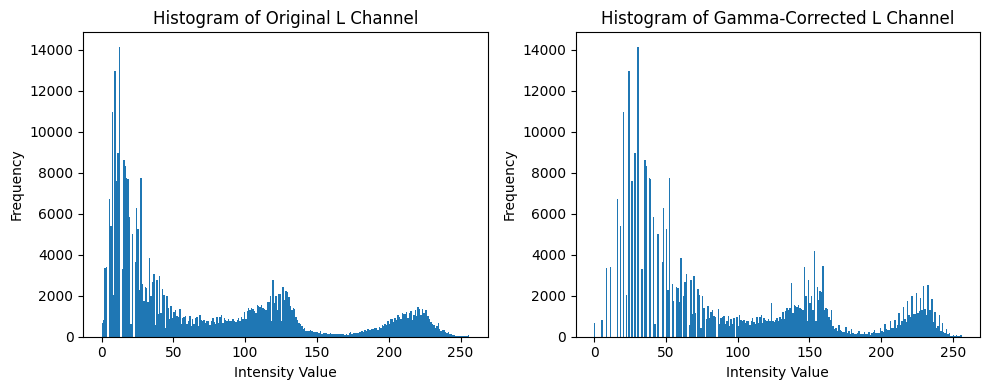

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of Original L Channel')    
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of Gamma-Corrected L Channel')
plt.xlabel('Intensity Value')   
plt.ylabel('Frequency')

plt.tight_layout()  
plt.show()

# Question 4 — Vibrance Enhancement

The image is converted from BGR to HSV.

The saturation plane is modified using the intensity transformation given
in the assignment.

The hue and value planes remain unchanged.

The parameter a controls the strength of the vibrance enhancement.

In [ ]:
img4 = cv.imread('images/4.png')

if img4 is None:
    raise FileNotFoundError("Image not found. Please check the path.")

hsv = cv.cvtColor(img4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

sigma = 70 
a_value = 0.6
S_float = S.astype(np.float32)
S_new = S_float + a_value* 128 * np.exp(-((S_float - 128) ** 2) / (2 * sigma ** 2))
S_new = np.clip(S_new, 0, 255).astype(np.uint8)

hsv_new = cv.merge((H, S_new, V))
vibrance = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

x = np.arange(256)
transformation = np.minimum(255, x + a_value * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)))

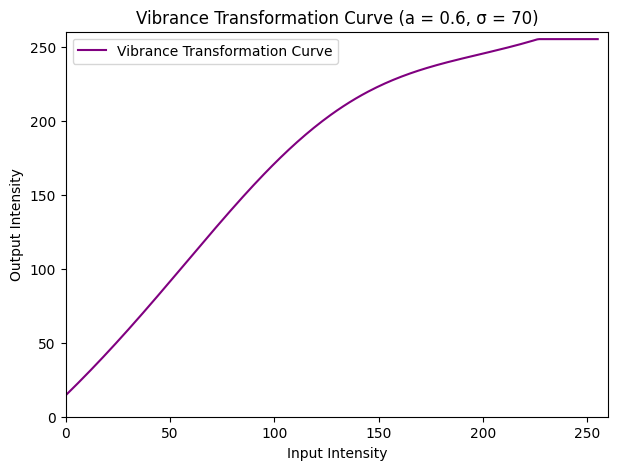

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(x, transformation, color='purple', label='Vibrance Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title(f"Vibrance Transformation Curve (a = {a_value}, σ = {sigma})")
plt.xlim(0, 260)
plt.ylim(0, 260)
plt.legend()
plt.show()


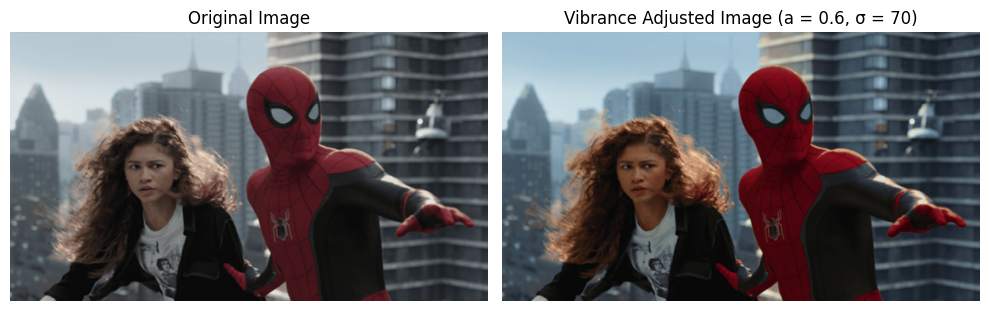

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(vibrance, cv.COLOR_BGR2RGB))
plt.title(f'Vibrance Adjusted Image (a = {a_value}, σ = {sigma})')
plt.axis('off')

plt.tight_layout()
plt.show()


# Question 5 — Histogram Equalization

Histogram equalization is implemented manually.

The algorithm consists of:

1. Computing the image histogram.
2. Computing the cumulative distribution function.
3. Normalizing the cumulative distribution.
4. Creating a lookup table.
5. Mapping the original intensities using the lookup table.

In [ ]:
def histogram_equalization(im):
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    nonzero = cdf[cdf > 0]

    if len(nonzero) == 0:
        return im.copy()

    cdf_min = nonzero[0]
    total_pixels = im.size
    denominator = total_pixels - cdf_min

    if denominator == 0:
        return im.copy()

    lut= ((cdf - cdf_min) / denominator * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    equalized_im = lut[im]
    return equalized_im

In [ ]:
img5 = cv.imread('images/5.png', cv.IMREAD_GRAYSCALE)

if img5 is None:
    raise FileNotFoundError("Image not found. Please check the path.")

equalized_img5 = histogram_equalization(img5)

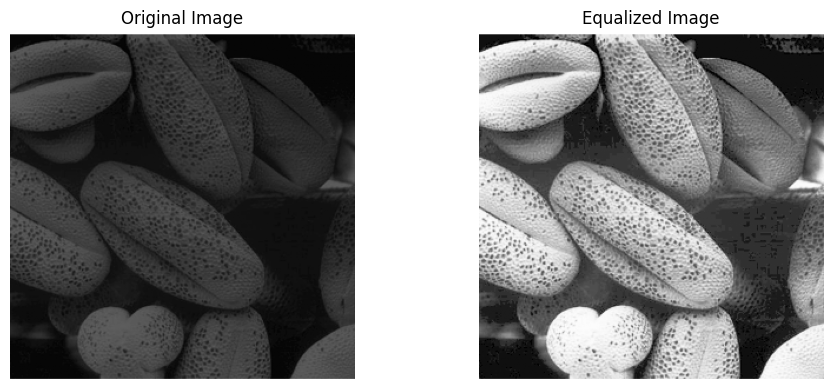

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img5, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_img5, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

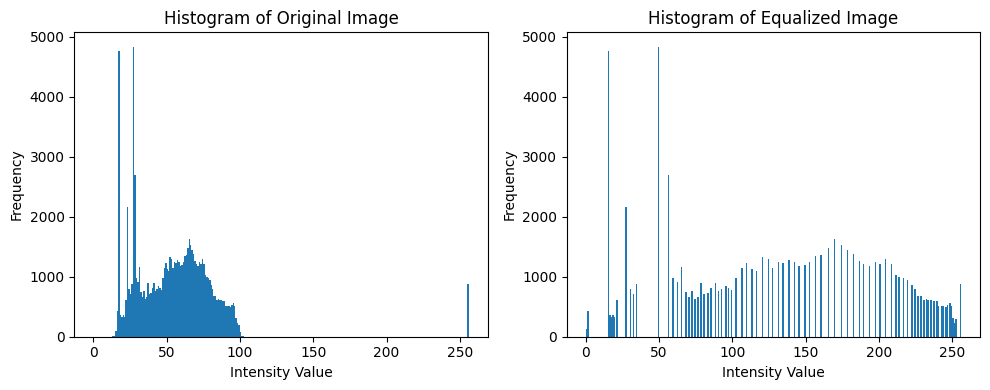

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img5.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of Original Image')
plt.xlabel('Intensity Value')   
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(equalized_img5.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of Equalized Image')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Question 6 — Histogram Equalization of the Foreground

In this question, histogram equalization is applied only to the
foreground.

The procedure is:

1. Convert the image to HSV.
2. Display the H, S, and V planes.
3. Select an appropriate plane for thresholding.
4. Generate a binary foreground mask.
5. Extract the foreground.
6. Calculate the foreground histogram.
7. Calculate the cumulative sum.
8. Equalize the foreground.
9. Extract the background.
10. Combine the equalized foreground with the original background.

In [ ]:
img6 = cv.imread('images/6.png')

if img6 is None:
    raise FileNotFoundError("Image not found. Please check the path.")

hsv_img6 = cv.cvtColor(img6, cv.COLOR_BGR2HSV)
H6, S6, V6 = cv.split(hsv_img6)

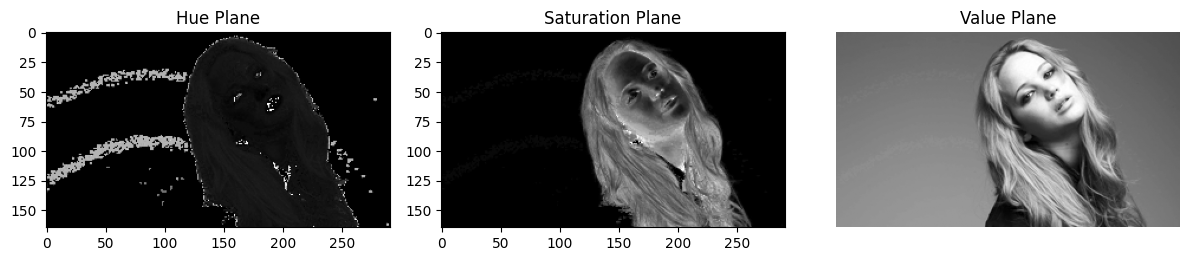

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H6, cmap='gray')
plt.title('Hue Plane')

plt.subplot(1, 3, 2)
plt.imshow(S6, cmap='gray') 
plt.title('Saturation Plane')

plt.subplot(1, 3, 3)
plt.imshow(V6, cmap='gray')
plt.title('Value Plane')

plt.axis('off')
plt.tight_layout()  
plt.show()

In [ ]:
threshold_value = 80

_, mask6 = cv.threshold(S6, threshold_value, 255, cv.THRESH_BINARY)
kernel = np.ones((5, 5), np.uint8)
mask6 = cv.morphologyEx(mask6, cv.MORPH_OPEN, kernel)
mask6 = cv.morphologyEx(mask6, cv.MORPH_CLOSE, kernel)

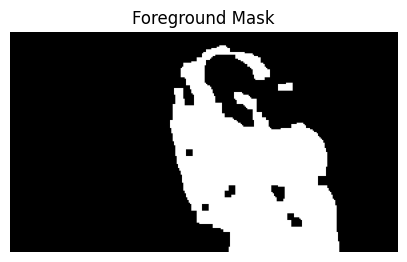

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(mask6, cmap='gray')
plt.title("Foreground Mask")
plt.axis('off')
plt.show()

In [ ]:
foreground6 = cv.bitwise_and(img6, img6, mask=mask6)
gray6 = cv.cvtColor(foreground6, cv.COLOR_BGR2GRAY)

foreground_pixels = gray6[mask6 > 0]
hist6 = np.bincount(foreground_pixels, minlength=256)
cdf6 = np.cumsum(hist6)

nonzero = cdf6[cdf6 > 0]
cdf_min = nonzero[0]
total_foreground_pixels = foreground_pixels.size
denominator = total_foreground_pixels - cdf_min
lut6 = ((cdf6 - cdf_min) / denominator * 255)
lut6 = np.clip(lut6, 0, 255).astype(np.uint8)

equalized_foreground_gray = np.zeros_like(gray6)
equalized_foreground_gray[mask6 > 0] = lut6[gray6[mask6 > 0]]

background_mask6 = cv.bitwise_not(mask6)
background6 = cv.bitwise_and(img6, img6, mask=background_mask6)

equalized_foreground6 = cv.cvtColor(equalized_foreground_gray, cv.COLOR_GRAY2BGR)
result6 = background6.copy()
result6[mask6 > 0] = equalized_foreground6[mask6 > 0]

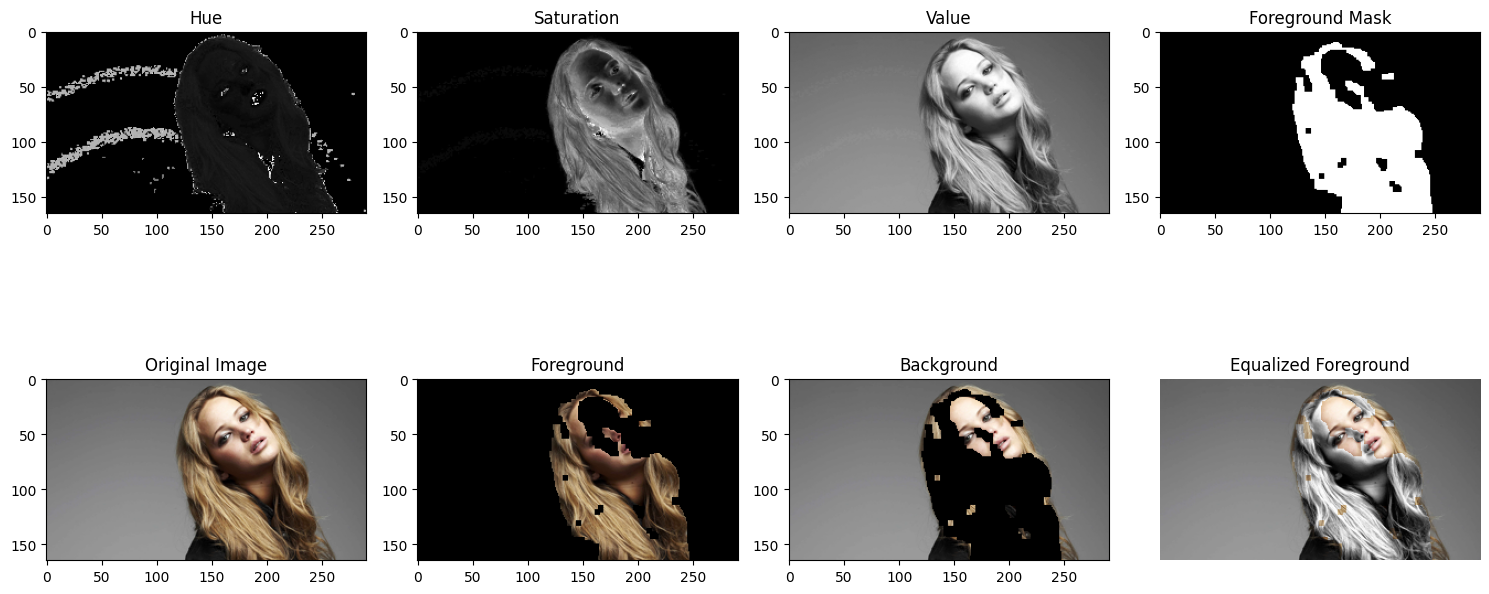

In [ ]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(H6, cmap='gray')
plt.title('Hue')

plt.subplot(2, 4, 2)
plt.imshow(S6, cmap='gray')
plt.title('Saturation')

plt.subplot(2, 4, 3)
plt.imshow(V6, cmap='gray')     
plt.title('Value')

plt.subplot(2, 4, 4)
plt.imshow(mask6, cmap='gray')
plt.title('Foreground Mask')

plt.subplot(2, 4, 5)
plt.imshow(cv.cvtColor(img6, cv.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(2, 4, 6)
plt.imshow(cv.cvtColor(foreground6, cv.COLOR_BGR2RGB))
plt.title('Foreground')

plt.subplot(2, 4, 7)
plt.imshow(cv.cvtColor(background6, cv.COLOR_BGR2RGB))
plt.title('Background')

plt.subplot(2, 4, 8)
plt.imshow(cv.cvtColor(result6, cv.COLOR_BGR2RGB))  
plt.title('Equalized Foreground')

plt.axis('off')
plt.tight_layout()
plt.show()

# Question 7 — Sobel Filtering

The Sobel operator estimates image gradients.

Two kernels are used:

Sobel X detects horizontal intensity changes and vertical edges.

Sobel Y detects vertical intensity changes and horizontal edges.

The gradient magnitude is calculated from the X and Y gradients.

In [ ]:
img7 = cv.imread('images/7.png', cv.IMREAD_GRAYSCALE)

if img7 is None:
    raise FileNotFoundError("Image not found. Please check the path.")

sobel_x_kernel = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                            [-1, 0, 1]], dtype=np.float32)

sobel_y_kernel = np.array([[-1, -2, -1],
                            [ 0,  0,  0],
                             [ 1,  2,  1]], dtype=np.float32)

NameError: name 'cv' is not defined

In [ ]:
gx = cv.filter2D(img7, cv.CV_32F, sobel_x_kernel)
gy = cv.filter2D(img7, cv.CV_32F, sobel_y_kernel)

magnitude = np.sqrt(gx**2 + gy**2)
magnitude = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

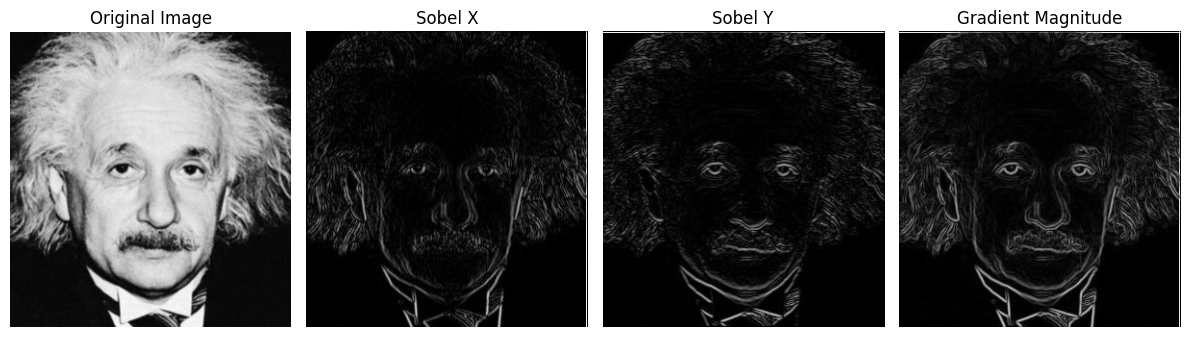

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img7, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(np.abs(gx), cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(np.abs(gy), cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off') 

plt.tight_layout()
plt.show()

In [ ]:
def filter2D_custom(im, kernel):
    im = im.astype(np.float32)
    kernel = kernel.astype(np.float32)
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    padded_im = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    h, w = im.shape
    result = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded_im[i:i + kh, j:j + kw]
            result[i, j] = np.sum(region * kernel)
    return result

In [ ]:
gx_custom = filter2D_custom(img7, sobel_x_kernel)
gy_custom = filter2D_custom(img7, sobel_y_kernel)
magnitude_custom = np.sqrt(gx_custom**2 + gy_custom**2)
magnitude_custom = cv.normalize(magnitude_custom, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

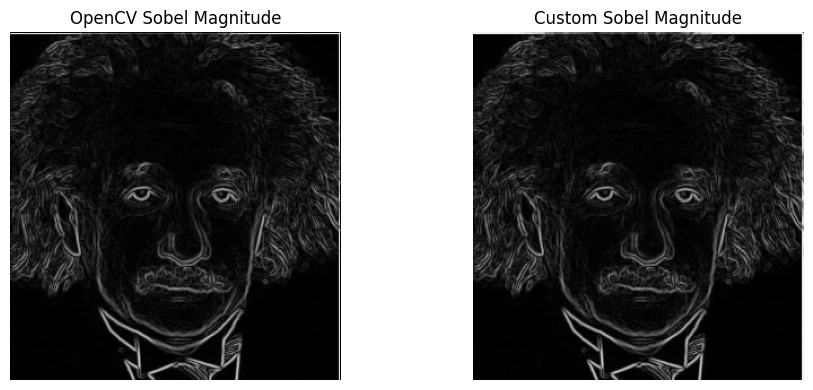

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('OpenCV Sobel Magnitude')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_custom, cmap='gray')
plt.title('Custom Sobel Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

## 7(c) Separable Sobel Filtering

The Sobel X kernel can be represented as the product of a vertical
smoothing kernel and a horizontal derivative kernel:

[1  2  1]^T * [1  0  -1]

This allows the 3×3 convolution to be performed using two smaller
one-dimensional operations.

In [ ]:
smooth_vertical = np.array([[1], [2], [1]], dtype=np.float32)
derivative_horizontal = np.array([[1, 0, -1]], dtype=np.float32)
temp_x = cv.filter2D(img7, cv.CV_32F, smooth_vertical)
gx_separable = cv.filter2D(temp_x, cv.CV_32F, derivative_horizontal)

smooth_horizontal = np.array([[1, 2, 1]], dtype=np.float32)
derivative_vertical = np.array([[1], [0], [-1]], dtype=np.float32)
temp_y = cv.filter2D(img7, cv.CV_32F, smooth_horizontal)
gy_separable = cv.filter2D(temp_y, cv.CV_32F, derivative_vertical)  

magnitude_separable = np.sqrt(gx_separable**2 + gy_separable**2)
magnitude_separable = cv.normalize(magnitude_separable, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

### Discussion

The Sobel operator successfully detects strong intensity changes in the
image. The manually implemented Sobel filter produces a result similar
to OpenCV's filter2D implementation.

The separable implementation performs the filtering using two
one-dimensional operations instead of one two-dimensional operation.
This can reduce computational complexity.

# Question 8 — Image Zooming

An image zooming function is implemented using two interpolation methods:

1. Nearest-neighbor interpolation.
2. Bilinear interpolation.

The reconstructed images are compared using normalized SSD.

In [ ]:
def zoom_nearest(im, s):
    h, w = im.shape[:2]
    new_h, new_w = int(h * s), int(w * s)
    zoomed_im = np.zeros((new_h, new_w), dtype=im.dtype)

    for y in range(new_h):
        src_y = int(y / s)
        if src_y >= h:
            src_y = h - 1
        for x in range(new_w):
            src_x = int(x / s)
            if src_x >= w:
                src_x = w - 1
            zoomed_im[y, x] = im[src_y, src_x]
    return zoomed_im

def zoom_bilinear(im, s):
    h, w = im.shape[:2]
    new_h, new_w = int(h * s), int(w * s)
    zoomed_im = np.zeros((new_h, new_w), dtype=np.float32)

    for y in range(new_h):
        src_y = y / s
        y0 = int(np.floor(src_y))
        y1 = min(y0 + 1, h - 1)
        dy = src_y - y0

        for x in range(new_w):
            src_x = x / s
            x0 = int(np.floor(src_x))
            x1 = min(x0 + 1, w - 1)
            dx = src_x - x0

            top_left = im[y0, x0]
            top_right = im[y0, x1]
            bottom_left = im[y1, x0]
            bottom_right = im[y1, x1]

            top = (1 - dx) * top_left + dx * top_right
            bottom = (1 - dx) * bottom_left + dx * bottom_right
            zoomed_im[y, x] = (1 - dy) * top + dy * bottom

    return np.clip(zoomed_im, 0, 255).astype(im.dtype)

def normalized_ssd(original, reconstructed):
    original = original.astype(np.float32)
    reconstructed = reconstructed.astype(np.float32)
    mse = np.mean((original - reconstructed) ** 2)
    normalized = mse / (255.0 ** 2)
    return normalized


In [ ]:
small = cv.imread(r"images\im01small.png", cv.IMREAD_GRAYSCALE)
large = cv.imread(r"images\im01.png", cv.IMREAD_GRAYSCALE)

if small is None:raise FileNotFoundError("Could not find im01small.png")
if large is None:raise FileNotFoundError("Could not find im01.png")

scale = 4
nearest8 = zoom_nearest(small, scale)
bilinear8 = zoom_bilinear(small, scale)

if nearest8.shape != large.shape: nearest8 = cv.resize(nearest8, (large.shape[1], large.shape[0]), interpolation=cv.INTER_NEAREST)
if bilinear8.shape != large.shape: bilinear8 = cv.resize(bilinear8, (large.shape[1], large.shape[0]), interpolation=cv.INTER_LINEAR)

ssd_nearest = normalized_ssd(large, nearest8)
ssd_bilinear = normalized_ssd(large, bilinear8)

print("Nearest-neighbor normalized SSD", ssd_nearest)
print("Bilinear normalized SSD", ssd_bilinear)

NameError: name 'cv' is not defined